# Error Analysis

## Combine Results

In [2]:
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "Naive Bayes",
        "Features": "CountVectorizer",
        "Accuracy": 0.8255,
        "Precision": 0.8548,
        "Recall": 0.7258,
        "F1": 0.7851
    },
    {
        "Model": "Logistic Regression",
        "Features": "TF-IDF",
        "Accuracy": 0.8341,
        "Precision": 0.8218,
        "Recall": 0.7945,
        "F1": 0.8079
    },
    {
        "Model": "Logistic Regression",
        "Features": "TF-IDF + Engineered Features",
        "Accuracy": 0.8390,
        "Precision": 0.8269,
        "Recall": 0.8009,
        "F1": 0.8137
    },
    {
        "Model": "DistilBERT",
        "Features": "Contextual Embeddings",
        "Accuracy": 0.9347,
        "Precision": 0.9396,
        "Recall": 0.9096,
        "F1": 0.9244
    }
])

results

,Model,Features,Accuracy,Precision,Recall,F1
0,Naive Bayes,CountVectorizer,0.8255,0.8548,0.7258,0.7851
1,Logistic Regression,TF-IDF,0.8341,0.8218,0.7945,0.8079
2,Logistic Regression,TF-IDF + Engineered Features,0.8390,0.8269,0.8009,0.8137
3,DistilBERT,Contextual Embeddings,0.9347,0.9396,0.9096,0.9244


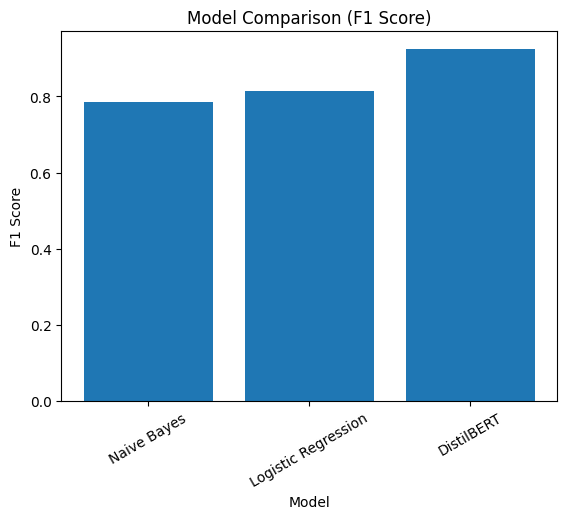

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["F1"])
plt.title("Model Comparison (F1 Score)")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.show()

## Error Analysis

In [14]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [15]:
import pandas as pd

bert_preds = pd.read_csv("../data/processed/bert_predictions.csv")
bert_preds.head()

,headline,actual,predicted
0,the outsider has officially squeezed its way inside the art world,0,0
1,lgbtq activists organizing massive dance protest at trump hotel,0,0
2,"romney dominated debate, say pundits trying to figure out gop candidate's policies",1,1
3,israeli soldiers open fire on palestinians carrying potentially dangerous injured friends,1,0
4,learned sage points out that powerball not as much after taxes,1,1


In [16]:
misclassified = bert_preds[bert_preds["actual"] != bert_preds["predicted"]]
correct = bert_preds[bert_preds["actual"] == bert_preds["predicted"]]

print("Total:", len(bert_preds))
print("Misclassified:", len(misclassified))
print("Correct:", len(correct))

Total: 5342
Misclassified: 358
Correct: 4984


In [17]:
misclassified.sample(10, random_state=42)

,headline,actual,predicted
3537,indian-american couple's accent makes fight adorable,1,0
872,leather-clad nomads seize power in australia,1,0
4053,ice agents hurl pregnant immigrant over mexican border to prevent birth on u.s. soil,1,0
4549,oxfam: 'your donation will help us protect impoverished girls from our employees',1,0
1021,joe arpaio's family surprises him with detained hispanic motorist,1,0
4503,jeff bezos named amazon employee of the month,1,0
307,bob dole for windows to replace bob dole 4.0,1,0
1024,scientists confirm there's nothing but misinformation on anti-vax sites,0,1
3873,andrew w.k. adopts staunch party-advocacy position,1,0
1959,french catering company employs refugees to cook their native foods,0,1


In [18]:
correct.sample(10, random_state=42)

,headline,actual,predicted
1590,perfect gentleman does not assault drunk woman,1,1
2933,"1994 video-store receipt reveals clinton rented night eyes 2, 3",1,1
488,big banks call for 'strong' climate deal,0,0
2648,tv viewers outraged at timing of commercial break,1,1
706,bugs infesting area apartment have no clear goal,1,1
1170,hundreds in hollywood protest rampant sexual misconduct,0,0
70,the omar khadr settlement reaffirms canada's values,0,0
1027,area man likes food,1,1
3587,"obama's record-breaking fundraising effort bankrupting npr, world wildlife fund, aclu",1,1
1448,bianchi introduces new bike for blocking commuters on subway during rush hour,1,1
